Group ID: **4**

* Rajilatha Kandiah: rajilatha.rajendiram@students.bfh.ch
* Roland Angelo Roccaro: rolandangelo.roccaro@students.bfh.ch
* Gian-Luca Mantovani: mantogia@students.zhaw.ch

#### Reading instruction:
Do search for "Comment" which is always the heading used at where we comment on the seen/inspected results.

# CIFAR10 using PyTorch

## Preparation

### Importing packages

In [67]:
import torch
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix
from tqdm.notebook import tqdm
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from  datetime import datetime
from torchsummary import summary
import os
import pandas as pd

%matplotlib inline

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

### Downloading CIFAR10 dataset

In [3]:
Transform = transforms.ToTensor()
train_data = datasets.CIFAR10(
    root = 'data',
    train = True,                         
    transform = Transform, 
    download = True,            
)

test_data = datasets.CIFAR10(
    root = 'data', 
    train = False, 
    transform = Transform,
    download = True
)

100%|██████████| 170M/170M [00:11<00:00, 14.2MB/s] 


In [4]:
train_data

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [5]:
test_data

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [6]:
train_data.data.shape

(50000, 32, 32, 3)

In [7]:
len(train_data.targets)

50000

In [8]:
img, target = train_data[0]

In [9]:
img.shape

torch.Size([3, 32, 32])

### Visualization of CIFAR10 dataset


Size: torch.Size([3, 32, 32]) Label: 6


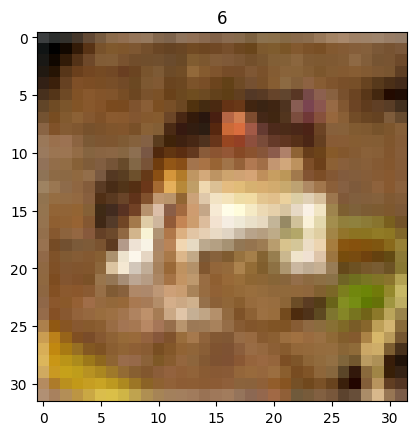

In [10]:
img, target = train_data[0]
image = img.permute(1, 2, 0)
print('Size:', img.size(), 'Label:', target)
plt.imshow(image)
plt.title('%i' % target)
plt.show()

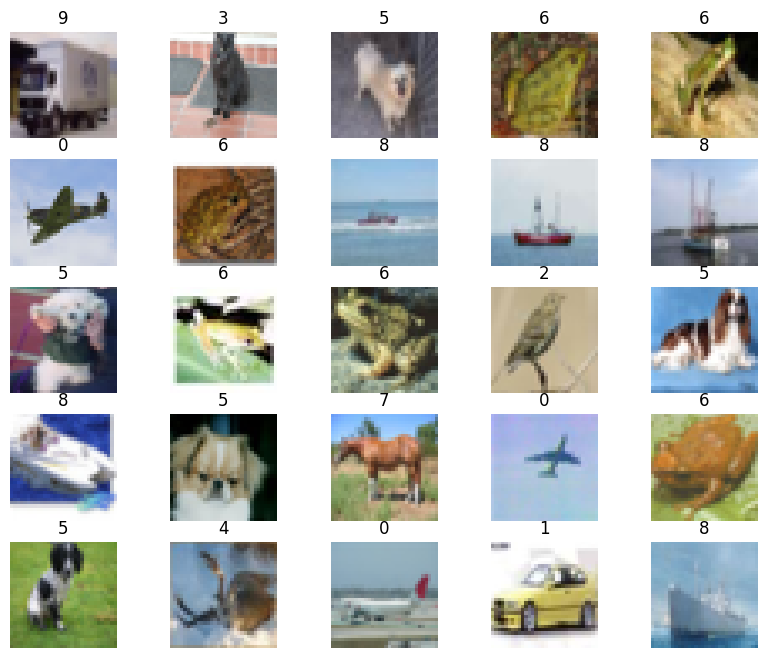

In [11]:
# Plot multiple train_data
def show_imgs(X):
    figure = plt.figure(figsize=(10, 8))
    cols, rows = 5, 5
    for i in range(1, cols * rows + 1):
        sample_idx = torch.randint(len(X), size=(1,)).item()
        img, label = X[sample_idx]
        figure.add_subplot(rows, cols, i)
        plt.title(label)
        plt.axis("off")
        plt.imshow(img.permute(1, 2, 0))
    plt.show()
    
show_imgs(train_data)

## One-layer network and weight visualisation

### Building the Network

In [33]:
example_img, example_target = train_data[0]
depth = example_img.shape[-1]
channels = example_img.shape[0]
depth, depth, channels

(32, 32, 3)

In [34]:
n_classes = len(set(train_data.targets))
n_classes

10

In [111]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(channels*depth*depth, n_classes)
        #self.fc1_drop = nn.Dropout(0.2)
        #self.fc2 = nn.Linear(50, 50)
        #self.fc2_drop = nn.Dropout(0.2)
        #self.fc3 = nn.Linear(50, 10)

    def forward(self, x):
        x = x.view(x.shape[0], -1)  # Beibehaltung von batch_size
        #x = torch.relu(self.fc1(x))
        #x = self.fc1_drop(x)
        #x = torch.relu(self.fc2(x))
        #x = self.fc2_drop(x)
        return self.fc1(x)

### Training and evaluating the Model

#### Methods

In [152]:
def train(epoch, model, data_loader, log_interval=200):
    # Set model to training mode
    model.train()
    total_train_loss = 0
    total_correct = 0

    use_tqdm = False  # Set to False to disable tqdm

    # Use tqdm only if use_tqdm is True
    data_iterator = tqdm(data_loader, desc=f"Training Epoch {epoch}") if use_tqdm else data_loader
    
    # Loop over each batch from the training set
    for batch_idx, (data, target) in enumerate(data_iterator):
        # Copy data to GPU if needed
        data = data.to(device)
        target = target.to(device)

        # Reset the gradient buffers to zero
        optimizer.zero_grad() 
        
        # Pass data through the network
        output = model(data)
        
        #print(f"Data shape: {data.shape}")
        #print(f"Output shape: {output.shape}")
        #print(f"Target shape: {target.shape}")

        # Calculate loss
        loss = criterion(output, target)

        # Backpropagate
        # Updates the gradients buffer on each parameter
        loss.backward()
        
        # Update weights
        # Applies the calcualted gradients to each parameter
        # based on the selected optimizer and its configuration.
        # such as the learning rate.
        optimizer.step()
        
        total_train_loss += loss.item()
        
        # The maximum value of dimension 1 (class dimension)
        # is the predicted class. Only the class index is
        # relevant, hence the first return value is ignored.
        # as: values, indices = torch.max(output, dim=1)
        _, pred = torch.max(output, dim=1)
        
        # pred == target gives a boolean tensor, where each
        # element represents whether it was correctly predicted.
        # Taking the sum gives the number of correct predictions
        # for this particular batch.
        total_correct += torch.sum(pred == target).item()
                  
        
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(data_loader.dataset),
                100. * batch_idx / len(data_loader), loss.data.item()))
    
    
    # Divided by len(data_loader.dataset) because it's the number
    # of correct predictions in total.
    accuracy_train = total_correct / len(data_loader.dataset)

    # Divided by len(data_loader) because it is the sum across
    # all batches, therefore it's divided by the number of batches.
    # There is a difference in the length of the data_loader compared
    # to the underlying dataset, which the data_loader partitions into
    # batches:
    #   - len(data_loader) == number of batches the dataloader can create
    #   - len(data_loader.dataset) == number of samples in the dataset
    total_train_loss = total_train_loss / len(data_loader)

    return {
        "loss": total_train_loss,
        "accuracy": accuracy_train,
    }

In [153]:
# torch.inference_mode() disables certain features that are not required
# for inference, such as autograd and other tracking.
# It's optional, but improves performance.
# Alternative: @torch.no_grad(), which only disables autograd. 
@torch.inference_mode()
def validate(model, data_loader):
    # Put the model in eval mode, which disables
    # training specific behaviour, such as Dropout.
    model.eval()
    
    val_loss = 0
    total_correct = 0
    total_preds = []
    total_targets = []
    
    use_tqdm = False  # Set to False to disable tqdm
    
    data_iterator = tqdm(data_loader, desc=f"Validation") if use_tqdm else data_loader
    
    for data, target in data_iterator:
        data = data.to(device)
        target = target.to(device)
        output = model(data)
        val_loss += criterion(output, target).item()
        
        _, pred = torch.max(output, dim=1)
        total_correct += torch.sum(pred == target).item()
        # Keep the predictions and targets to inspect later on.
        # .detach() decouples it from the computational graph
        # and .cpu() ensures it's on the CPU, since it shouldn't
        # occupy any unnecesary GPU memory.
        total_preds.append(pred.detach().cpu())
        # target isn't tracked in the computational graph
        # (it's a leaf with requires_grad=False), adding the
        # .detach() doesn't do anything, but if in doubt, just add it.
        total_targets.append(target.cpu())

    val_loss /= len(data_loader)
    accuracy = total_correct / len(data_loader.dataset)
    
    print('\nValidation set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
        val_loss, total_correct, len(data_loader.dataset), 100 * accuracy))
    
    return {
        "loss": val_loss,
        "accuracy": accuracy,
        "predictions": torch.cat(total_preds),
        "targets": torch.cat(total_targets),

    }

In [154]:
# This function simplifies the training loop,
# makes it callable easily without needing to redefine it
def train_validate(model, train_loader, test_loader, epochs=5):

    # Keep track of stats to plot them
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(1, epochs + 1):
        train_result = train(epoch, model, train_loader)
        train_losses.append(train_result["loss"])
        train_accuracies.append(train_result["accuracy"])
        
        val_result = validate(model, test_loader)
        val_losses.append(val_result["loss"])
        val_accuracies.append(val_result["accuracy"])
        
    return train_losses, train_accuracies, val_losses, val_accuracies

In [220]:
# This function generates a model name
# It is used to save settings of each model
def create_model_name(model, hp):
    # Get model architecture details
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    is_cnn = False
    for name, layer in model.named_modules():
        if isinstance(layer, nn.Conv2d):
            is_cnn = True
            break
    num_conv_layers = sum(1 for layer in model.modules() if isinstance(layer, nn.Conv2d))
    # Auto-generate model name
    if is_cnn:
        return  f"{model.__class__.__name__}_Conv{num_conv_layers}_Params{total_params}_Opt{hp['optimizer']}_EP{hp['epochs']}_LR{hp['lr']}_WD{hp['weight_decay']}"
    model_name = f"{model.__class__.__name__}_Params{total_params}_Opt{hp['optimizer']}_EP{hp['epochs']}_LR{hp['lr']}_WD{hp['weight_decay']}"
    return model_name

In [68]:
# This function will store the results of a model into our .csv
def store_results(model_name, train_losses, train_accuracies, val_losses, val_accuracies, epochs, file_path="model_training_results.csv"):
    """
    Stores and appends training results to a CSV file after removing existing entries of the same model.

    Parameters:
        model_name (str): Name of the model.
        train_losses (list): List of training loss values per epoch.
        train_accuracies (list): List of training accuracy values per epoch.
        val_losses (list): List of validation loss values per epoch.
        val_accuracies (list): List of validation accuracy values per epoch.
        epochs (int): Number of epochs.
        file_path (str): Path to the CSV file where results will be stored.
    """
    
    # Create a DataFrame with the new results
    new_df = pd.DataFrame({
        "Epoch": list(range(1, epochs + 1)),
        "Train Loss": train_losses,
        "Train Accuracy": train_accuracies,
        "Validation Loss": val_losses,
        "Validation Accuracy": val_accuracies,
        "Model Name": [model_name] * epochs  # Repeat model name for all rows
    })

    # Check if the file exists
    if os.path.exists(file_path):
        # Load existing data
        existing_df = pd.read_csv(file_path)

        # Remove rows where "Model Name" matches the new model_name
        existing_df = existing_df[existing_df["Model Name"] != model_name]

        # Append new results
        updated_df = pd.concat([existing_df, new_df], ignore_index=True)
    else:
        # If file doesn't exist, create a new DataFrame
        updated_df = new_df

    # Save the updated DataFrame back to the CSV file
    updated_df.to_csv(file_path, index=False)
    
    return updated_df

In [1]:
# Function callable to plot training results
# Will plot the values we have for each epoch of each model from the file we store these values from
def plot_training_results(file_path="model_training_results.csv", only_cnn = False):

    # Check if the file exists
    if not os.path.exists(file_path):
        print(f"File {file_path} not found. No training results to plot.")
        return
    
    # Load the DataFrame
    df = pd.read_csv(file_path)
    
    # Get unique model names
    unique_models = df["Model Name"].unique()
    

    # Function to shorten model names
    def shorten_model_name(full_name):
        if "CNN" in full_name:
            return full_name.split("_")[0] + "_" + full_name.split("_")[1] + "_" + full_name.split("_")[5] + full_name.split("_")[6]
        if "two_layers" in full_name:
            return full_name.split("_")[0] + "2_" + full_name.split("_")[6] + full_name.split("_")[7]
        return full_name.split("_")[0] + "_" + full_name.split("_")[4] + full_name.split("_")[5]
    
    # LOSS PLOT
    plt.figure(figsize=(12, 5))

    for model_name in unique_models:
        if "net" in model_name.lower() and only_cnn:
            continue
        model_df = df[df["Model Name"] == model_name]
        short_name = shorten_model_name(model_name)
        plt.plot(model_df["Epoch"], model_df["Train Loss"], label=f"{short_name} - Train Loss")
        plt.plot(model_df["Epoch"], model_df["Validation Loss"], label=f"{short_name} - Val Loss")

    plt.title("Loss Plot")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()

    # ACCURACY PLOT
    plt.figure(figsize=(12, 5))

    for model_name in unique_models:
        if "net" in model_name.lower() and only_cnn:
            continue
        model_df = df[df["Model Name"] == model_name]
        short_name = shorten_model_name(model_name)
        plt.plot(model_df["Epoch"], model_df["Train Accuracy"], label=f"{short_name} - Train Acc")
        plt.plot(model_df["Epoch"], model_df["Validation Accuracy"], label=f"{short_name} - Val Acc")

    plt.title("Accuracy Plot")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid()
    plt.show()

#### Instances

In [96]:
hp = {
    "epochs":5,
    "batch_size":128,
    "lr": 0.001,
    "weight_decay":0.05,
    "optimizer":"Adam"
    }

train_loader = DataLoader(train_data, batch_size=hp["batch_size"], shuffle=True)
test_loader = DataLoader(test_data, batch_size=hp["batch_size"], shuffle=False)
model = Net().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=hp["lr"], weight_decay=hp["weight_decay"])
criterion = nn.CrossEntropyLoss()

In [ ]:
train_losses, train_accuracies, val_losses, val_accuracies = train_validate(model, train_loader, test_loader, epochs=hp["epochs"])

In [98]:
model_name = create_model_name(model, hp)
df = store_results(model_name, train_losses, train_accuracies, val_losses, val_accuracies, hp["epochs"])
df.head()

,Epoch,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy,Model Name
0,1,1.934157,0.31294,1.857626,0.3539,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
1,2,1.863742,0.34412,1.936205,0.2949,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
2,3,1.860499,0.34854,1.842625,0.3463,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
3,4,1.859108,0.34610,1.919166,0.3198,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
4,5,1.861645,0.34672,1.873598,0.3364,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05


### Loss and Accuracy evaluation during training

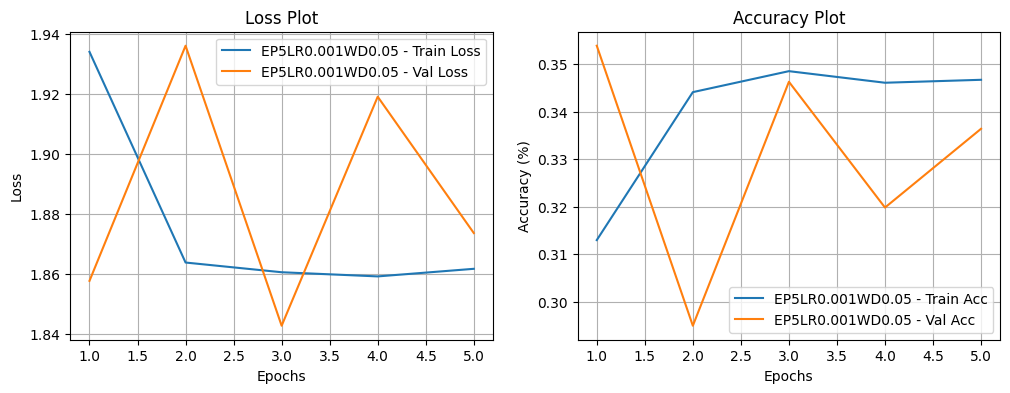

In [100]:
plot_training_results()

### Comment
__Remarks:__

The training accuracy is around 35%, indicating poor performance. Although there is a slight improvement in training accuracy over the epochs, the model struggles to generalize to unseen data.

During these 5 epochs, the performance on the validation set does not show consistent improvements and fluctuates significantly. This suggests that the model is underfitting.

### Confusion matrix


In [101]:
# val_result is from the validation of the last epoch above.
# But you could run it specifically with:

val_result = validate(model, test_loader)

cm = confusion_matrix(val_result["predictions"], val_result["targets"])
print(cm)

Validation:   0%|          | 0/79 [00:00<?, ?it/s]


Validation set: Average loss: 1.8736, Accuracy: 3364/10000 (33.64%)

[[160   7  23   2  12   3   1   2  14   7]
 [ 96 525  46  77  31  46  66  58 169 271]
 [314  90 575 260 514 293 326 285 116  70]
 [ 66  85 148 426 194 328 283 143  74  71]
 [  0   2   4   3  44   2  10  10   0   4]
 [  7  36  38  95  27 200  48  38  28   9]
 [  6  20  39  27  57  18 210  13   4  22]
 [ 43  36  44  39  73  61  22 351  23  52]
 [249  87  69  32  32  34  14  37 494 115]
 [ 59 112  14  39  16  15  20  63  78 379]]


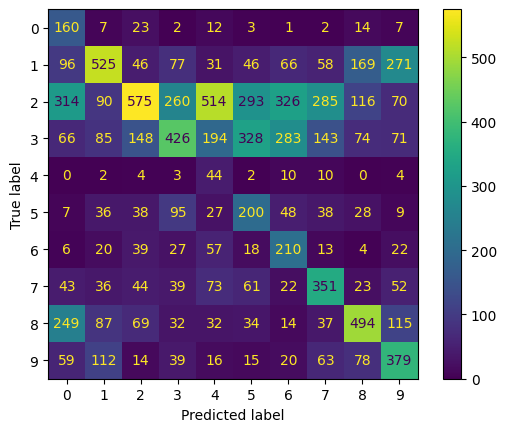

In [102]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

#### Comment
* The confusion matrix shows considerable confusion on most classes.
* In case of a good model we should see high values along the main diagonale
* However we observe for example at class 2, that even tough the value in the diagonale matching 2,2 is quite high on 575,
* the relative value is actually very bad on the true label line we have 314+90+575+260+514+293+326+285+116+70 = 2843
* 2843/575 = 0.20225
* Only 20% of the class is predicted correct
* another remark : in this confusion matrix we see a considerable inbalance of classes, class 2 and 3 are overrepresented

### Plot the weights

In [103]:
# The weight of the classification layer
classifier_weight = model.fc1.weight.detach().cpu()
classifier_weight.shape

torch.Size([10, 3072])

In [104]:
bias_values = model.fc1.bias.data
bias_values

tensor([-0.1251,  0.0605,  0.0336,  0.0326,  0.0491, -0.0390,  0.0665,  0.0164,
        -0.1042,  0.0081])

Weight of classification layer has size: torch.Size([10, 3072])


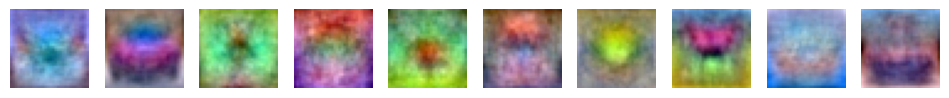

In [105]:
# The weight of the classification layer
classifier_weight = model.fc1.weight.detach().cpu()

print(f"Weight of classification layer has size: {classifier_weight.size()}")

fig = plt.figure(figsize=(12, 12))

# Reshape and plot each class weight as an image
num_classes = classifier_weight.shape[0]  # Number of output classes

for i, weight in enumerate(classifier_weight):
    ax = fig.add_subplot(1, num_classes, i + 1)

    # Reshape weight back to (3, 32, 32) for visualization
    weight_reshaped = weight.view(3, 32, 32)  

    # Normalize to 0-255
    min_value = torch.min(weight_reshaped)
    max_value = torch.max(weight_reshaped)
    im = torch.round((weight_reshaped - min_value) / (max_value - min_value) * 255).to(torch.uint8)

    # Convert (3, 32, 32) to (32, 32, 3) for RGB image display
    ax.imshow(im.permute(1, 2, 0))

    ax.axis('off')

plt.show()


## Two-layers network
Start with the following configuration : 128 neurons on the hidden layer, 30 training epochs, a
batch size of 128 images, a relu activation on the hidden layer, a softmax activation at the
output layer, categorical-crossentropy loss and adam optimizer. You don’t need to use a
L2 regularizer in this model. This configuration should give you an accuracy around 45% on
the test set

### Building the Network

In [108]:
example_img, example_target = train_data[0]
depth = example_img.shape[-1]
channels = example_img.shape[0]
depth, depth, channels

(32, 32, 3)

In [ ]:
n_classes = len(set(train_data.targets))
n_classes

10

In [110]:
class Net_two_layers(nn.Module):
    def __init__(self, n_neurons):
        super().__init__()
        self.fc1 = nn.Linear(channels*depth*depth, n_neurons)
        #self.fc1_drop = nn.Dropout(0.2)
        self.fc2 = nn.Linear(n_neurons, n_classes)
        #self.fc2_drop = nn.Dropout(0.2)
        #self.fc3 = nn.Linear(50, 10)

    def forward(self, x):
        x = x.view(x.shape[0], -1)  # Beibehaltung von batch_size
        x = torch.relu(self.fc1(x))
        #x = self.fc1_drop(x)
        #x = torch.relu(self.fc2(x))
        #x = self.fc2_drop(x)
        return self.fc2(x)

### Training and evaluating the Model

#### Instances

In [112]:
hp = {
    "epochs":30,
    "batch_size":128,
    "lr": 0.001,
    "weight_decay":0.00,
    "optimizer":"Adam"
    }

train_loader = DataLoader(train_data, batch_size=hp["batch_size"], shuffle=True)
test_loader = DataLoader(test_data, batch_size=hp["batch_size"], shuffle=False)
model = Net_two_layers(n_neurons=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=hp["lr"], weight_decay=hp["weight_decay"])
criterion = nn.CrossEntropyLoss()

In [ ]:
train_losses, train_accuracies, val_losses, val_accuracies = train_validate(model, train_loader, test_loader, epochs=hp["epochs"])

In [115]:
model_name = create_model_name(model, hp)
df = store_results(model_name, train_losses, train_accuracies, val_losses, val_accuracies, hp["epochs"])
df.head()

,Epoch,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy,Model Name
0,1,1.934157,0.31294,1.857626,0.3539,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
1,2,1.863742,0.34412,1.936205,0.2949,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
2,3,1.860499,0.34854,1.842625,0.3463,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
3,4,1.859108,0.34610,1.919166,0.3198,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
4,5,1.861645,0.34672,1.873598,0.3364,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05


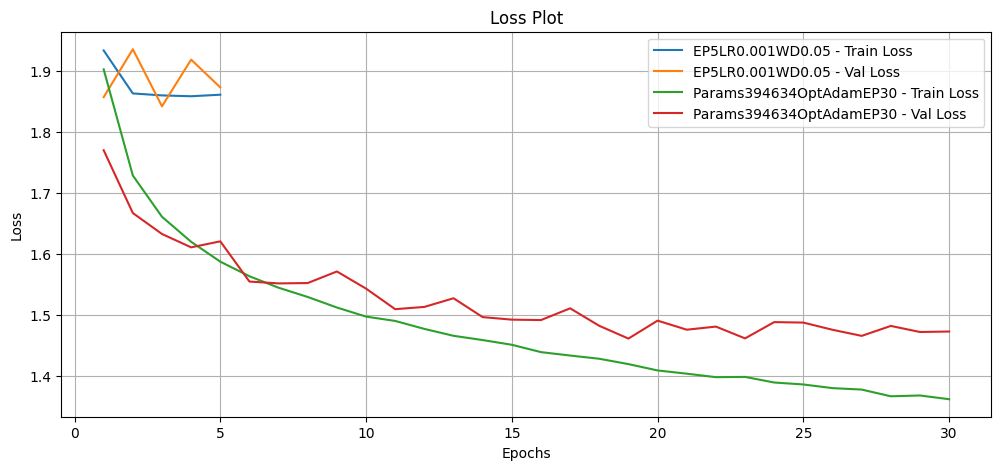

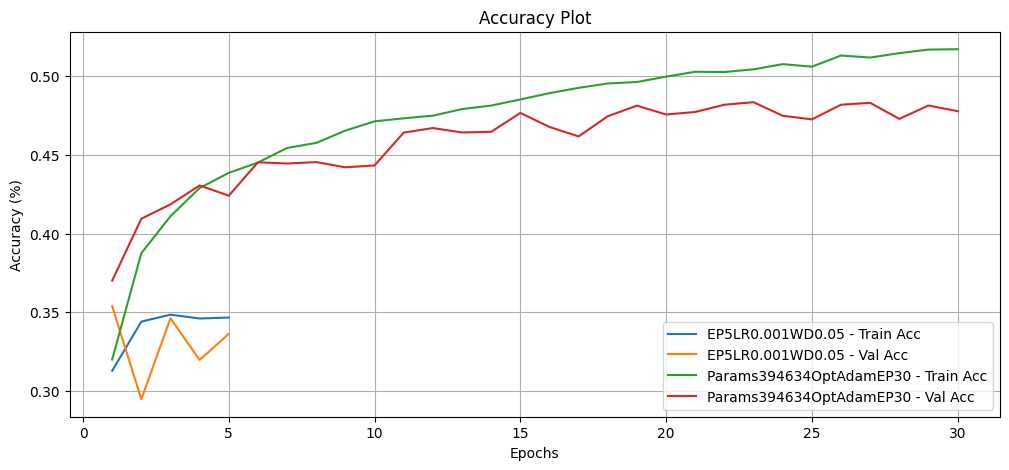

In [130]:
plot_training_results()

## Comment
Already the first model with 2 layers ( we used 3) show following traits:
* has a significantly bigger accuracy. at around 47% in validation
* However we can overfitting as the  trein and validation accuracy start drifting apart

### Exercise 2, tune Model
Make some tuning on the hyperparameters in order to improve the performances, e.g. by increasing the number of neurons, by adding fully connected layers, by tuning the number of
epochs, etc. Report your best performance.

* we used a Grid to combine multiple different hyperparameters

### dynamic class

In [120]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DynamicMLP(nn.Module):
    def __init__(self, layer_sizes, activation="relu", input_dropout=0.0, hidden_dropout=0.0):
        """."""
        super().__init__()

        self.layers = nn.ModuleList()
        self.activation = activation.lower()
        self.input_dropout = nn.Dropout(input_dropout) if input_dropout > 0 else None
        self.hidden_dropout = nn.Dropout(hidden_dropout) if hidden_dropout > 0 else None

        for i in range(len(layer_sizes) - 1):
            self.layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))

    def forward(self, x):
        x = x.view(x.shape[0], -1)  # Flatten input
        
        if self.input_dropout:
            x = self.input_dropout(x)

        for i, layer in enumerate(self.layers[:-1]):  # All layers except last
            x = layer(x)
            x = self.apply_activation(x)

            if self.hidden_dropout:
                x = self.hidden_dropout(x)

        x = self.layers[-1](x)
        return x

    def apply_activation(self, x):
        """Applies the chosen activation function."""
        if self.activation == "relu":
            return F.relu(x)
        elif self.activation == "tanh":
            return torch.tanh(x)
        elif self.activation == "sigmoid":
            return torch.sigmoid(x)
        elif self.activation == "none":
            return x  # No activation
        else:
            raise ValueError(f"Unknown activation function: {self.activation}")

In [118]:
example_img, example_target = train_data[0]
depth = example_img.shape[-1]
channels = example_img.shape[0]
n_classes = len(set(train_data.targets))


In [ ]:
hp = {
    "epochs":50,
    "batch_size":128,
    "lr": 0.001,
    "weight_decay":0.00,
    "optimizer":"Adam"
    }

train_loader = DataLoader(train_data, batch_size=hp["batch_size"], shuffle=True)
test_loader = DataLoader(test_data, batch_size=hp["batch_size"], shuffle=False)

layer_sizes = [channels * depth * depth, 128, 128, n_classes]

model = DynamicMLP(layer_sizes, activation="relu", input_dropout=0.2, hidden_dropout=0.3)
optimizer = torch.optim.Adam(model.parameters(), lr=hp["lr"], weight_decay=hp["weight_decay"])
criterion = nn.CrossEntropyLoss()

train_losses, train_accuracies, val_losses, val_accuracies = train_validate(model, train_loader, test_loader, epochs=hp["epochs"])

DynamicMLP(
  (layers): ModuleList(
    (0): Linear(in_features=3072, out_features=128, bias=True)
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
  (input_dropout): Dropout(p=0.2, inplace=False)
  (hidden_dropout): Dropout(p=0.3, inplace=False)
)


In [145]:
# Define possible values for each hyperparameter
# comment, see our param grid
param_grid = {
    "epochs": [50, 70, 90],
    "batch_size": [128],  
    "lr": [0.001, 0.006],
    "weight_decay": [0.0],  
    "optimizer": ["Adam"],
    "input_dropout": [0.0],
    "hidden_dropout": [0.0],
    "layer_sizes": [[channels * depth * depth, 128, 128, n_classes],
                    [channels * depth * depth, 256, 256, n_classes],
                    [channels * depth * depth, 256, 256, 256, n_classes]]
}


In [146]:
import itertools
# Generate all possible combinations of parameters
param_combinations = list(itertools.product(*param_grid.values()))
len(param_combinations)

18

In [147]:
for params in param_combinations:
    hp = dict(zip(param_grid.keys(), params))  # Convert tuple back to dictionary
    print(hp)

{'epochs': 50, 'batch_size': 128, 'lr': 0.001, 'weight_decay': 0.0, 'optimizer': 'Adam', 'input_dropout': 0.0, 'hidden_dropout': 0.0, 'layer_sizes': [3072, 128, 128, 10]}
{'epochs': 50, 'batch_size': 128, 'lr': 0.001, 'weight_decay': 0.0, 'optimizer': 'Adam', 'input_dropout': 0.0, 'hidden_dropout': 0.0, 'layer_sizes': [3072, 256, 256, 10]}
{'epochs': 50, 'batch_size': 128, 'lr': 0.001, 'weight_decay': 0.0, 'optimizer': 'Adam', 'input_dropout': 0.0, 'hidden_dropout': 0.0, 'layer_sizes': [3072, 256, 256, 256, 10]}
{'epochs': 50, 'batch_size': 128, 'lr': 0.006, 'weight_decay': 0.0, 'optimizer': 'Adam', 'input_dropout': 0.0, 'hidden_dropout': 0.0, 'layer_sizes': [3072, 128, 128, 10]}
{'epochs': 50, 'batch_size': 128, 'lr': 0.006, 'weight_decay': 0.0, 'optimizer': 'Adam', 'input_dropout': 0.0, 'hidden_dropout': 0.0, 'layer_sizes': [3072, 256, 256, 10]}
{'epochs': 50, 'batch_size': 128, 'lr': 0.006, 'weight_decay': 0.0, 'optimizer': 'Adam', 'input_dropout': 0.0, 'hidden_dropout': 0.0, 'layer

In [155]:
# Store results
results = []

# Perform Grid Search
for params in param_combinations:
    print(params)
    hp = dict(zip(param_grid.keys(), params))  # Convert tuple back to dictionary

    # Define Data Loaders
    train_loader = DataLoader(train_data, batch_size=hp["batch_size"], shuffle=True)
    test_loader = DataLoader(test_data, batch_size=hp["batch_size"], shuffle=False)

    # Create Model
    model = DynamicMLP(
        hp["layer_sizes"], 
        activation="relu", 
        input_dropout=hp["input_dropout"], 
        hidden_dropout=hp["hidden_dropout"]
    )

    # Set Optimizer
    if hp["optimizer"] == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=hp["lr"], weight_decay=hp["weight_decay"])
    elif hp["optimizer"] == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=hp["lr"], momentum=0.9, weight_decay=hp["weight_decay"])

    criterion = nn.CrossEntropyLoss()

    # Train and Validate Model
    train_losses, train_accuracies, val_losses, val_accuracies = train_validate(
        model, train_loader, test_loader, epochs=hp["epochs"]
    )

    # Store Results
    results.append({
        "Batch Size": hp["batch_size"],
        "Learning Rate": hp["lr"],
        "Weight Decay": hp["weight_decay"],
        "Optimizer": hp["optimizer"],
        "Input Dropout": hp["input_dropout"],
        "Hidden Dropout": hp["hidden_dropout"],
        "Layer Sizes": str(hp["layer_sizes"]),
        "Final Train Accuracy": train_accuracies[-1],
        "Final Validation Accuracy": val_accuracies[-1],
        "Final Train Loss": train_losses[-1],
        "Final Validation Loss": val_losses[-1]
    })

# Convert results into a DataFrame
df_results = pd.DataFrame(results)

(50, 128, 0.001, 0.0, 'Adam', 0.0, 0.0, [3072, 128, 128, 10])
Train Epoch: 1 [0/50000 (0%)]	Loss: 2.313179
Train Epoch: 1 [25600/50000 (51%)]	Loss: 1.828331

Validation set: Average loss: 1.7363, Accuracy: 3654/10000 (36.54%)

Train Epoch: 2 [0/50000 (0%)]	Loss: 1.671526
Train Epoch: 2 [25600/50000 (51%)]	Loss: 1.728184

Validation set: Average loss: 1.6455, Accuracy: 4155/10000 (41.55%)

Train Epoch: 3 [0/50000 (0%)]	Loss: 1.526256
Train Epoch: 3 [25600/50000 (51%)]	Loss: 1.573499

Validation set: Average loss: 1.5948, Accuracy: 4242/10000 (42.42%)

Train Epoch: 4 [0/50000 (0%)]	Loss: 1.598721
Train Epoch: 4 [25600/50000 (51%)]	Loss: 1.673441

Validation set: Average loss: 1.5459, Accuracy: 4514/10000 (45.14%)

Train Epoch: 5 [0/50000 (0%)]	Loss: 1.651297
Train Epoch: 5 [25600/50000 (51%)]	Loss: 1.409855

Validation set: Average loss: 1.5370, Accuracy: 4580/10000 (45.80%)

Train Epoch: 6 [0/50000 (0%)]	Loss: 1.534654
Train Epoch: 6 [25600/50000 (51%)]	Loss: 1.394024

Validation set: A

In [156]:
# Save results as csv
df_results.to_csv("grid_search_results.csv")

### Comment
We use a pandas dataframe to save performance of each model.
The results are saved as .csv to be able to compare when re-running code. And removing the need to run and create new models each time we want to compare them against each other, or for the final table at Exercise 3

### Results

In [169]:
df = pd.read_csv("grid_search_results.csv", index_col=0)

In [170]:
df

,Batch Size,Learning Rate,Weight Decay,Optimizer,Input Dropout,Hidden Dropout,Layer Sizes,Final Train Accuracy,Final Validation Accuracy,Final Train Loss,Final Validation Loss
0,128,0.001,0.0,Adam,0.0,0.0,"[3072, 128, 128, 10]",0.61524,0.5207,1.077436,1.423238
1,128,0.001,0.0,Adam,0.0,0.0,"[3072, 256, 256, 10]",0.71198,0.5118,0.803085,1.664202
2,128,0.001,0.0,Adam,0.0,0.0,"[3072, 256, 256, 256, 10]",0.79644,0.4948,0.560510,2.201586
3,128,0.006,0.0,Adam,0.0,0.0,"[3072, 128, 128, 10]",0.45382,0.4193,1.521096,1.628427
4,128,0.006,0.0,Adam,0.0,0.0,"[3072, 256, 256, 10]",0.40966,0.3935,1.640690,1.688268
5,128,0.006,0.0,Adam,0.0,0.0,"[3072, 256, 256, 256, 10]",0.45202,0.4348,1.511874,1.584474
6,128,0.001,0.0,Adam,0.0,0.0,"[3072, 128, 128, 10]",0.61218,0.5010,1.089264,1.470144
7,128,0.001,0.0,Adam,0.0,0.0,"[3072, 256, 256, 10]",0.75130,0.4908,0.696804,1.889877
8,128,0.001,0.0,Adam,0.0,0.0,"[3072, 256, 256, 256, 10]",0.86936,0.4854,0.360220,3.138152
9,128,0.006,0.0,Adam,0.0,0.0,"[3072, 128, 128, 10]",0.42286,0.4087,1.599818,1.650380


In [ ]:
import numpy as np
df[df["Final Validation Accuracy"] == np.max(df["Final Validation Accuracy"])]

,Batch Size,Learning Rate,Weight Decay,Optimizer,Input Dropout,Hidden Dropout,Layer Sizes,Final Train Accuracy,Final Validation Accuracy,Final Train Loss,Final Validation Loss
0,128,0.001,0.0,Adam,0.0,0.0,"[3072, 128, 128, 10]",0.61524,0.5207,1.077436,1.423238


In [ ]:
df[df["Final Train Accuracy"] == np.max(df["Final Train Accuracy"])] # overfitted

,Batch Size,Learning Rate,Weight Decay,Optimizer,Input Dropout,Hidden Dropout,Layer Sizes,Final Train Accuracy,Final Validation Accuracy,Final Train Loss,Final Validation Loss
14,128,0.001,0.0,Adam,0.0,0.0,"[3072, 256, 256, 256, 10]",0.88112,0.4864,0.32761,3.753903


__Comment:__

In total, we tested 18 different models, varying parameters such as epochs, learning rates, number of layers, and neurons per layer. However, we did not include the number of epochs in our results table, which prevents us from drawing direct conclusions about its impact. Nevertheless, we assume that the best-performing model likely trained for the maximum of 90 epochs. Other hyperparameters, such as batch size, weight decay, and optimizer settings, remained consistent across all models.

The best model, achieving an validation accuracy of 0.5207, consists of two hidden layers with 128 neurons each and a lower learning rate. Compared to other models, this architecture is relatively simple, which likely contributed to better generalization.

On the other hand, the model with the highest training accuracy 0.8811 was the most complex, featuring three hidden layers with 256 neurons each. However, this model struggled to generalize, achieving only 0.486 validation accuracy, indicating severe overfitting. To improve its generalization, regularization techniques such as Dropout or L2 weight decay.

# Exercise 3
## Simple CNN
Modify your MLP version from the previous exercise towards Convolutional Neural Networks.
###
Start with the following configuration :
— Keep your input shape equals to (32x32x3), i.e. you don’t need to re-shape your input
into a flattened vector. A given training sample Xi will hold the raw pixel values of the
i
th image of width 32, height 32, and with three color channels R,G,B.
— Insert a first convolutional layer Conv2D() with 32 filters and stride S = 1. With Keras
or Pytorch, you can let it compute the padding using the option padding=’same’ in the
arguments of the layer. This layer will compute the output of neurons that are connected
to local regions in the input, each computing a dot product between their weights and
4
a small region they are connected to in the input volume. This will result in an output
volume (32x32x32) as we decided to use 32 filters.
— Insert a ReLU layer that will apply an elementwise activation function, such as the
max(0,x) thresholding at zero. This leaves the size of the volume unchanged (32x32x32).
— Insert a 2D max pooling layer of size 2. This layer will perform a downsampling operation
along the spatial dimensions (width, height), resulting in a volume (16x16x32).
— CNN usually ends with a fully-connected (dense) layer that will compute the class scores,
resulting in a volume of size (1x1x10), where each of the 10 numbers correspond to a
class score. As with ordinary Neural Networks and as the name implies, each neuron in
this layer will be connected to all the values in the previous volume. For this reason, in
Keras, you first need to “flatten” the output volume of the previous layer, in our case
from (16,16,32) towards (1,8192). To do that use re-shaping layer to flatten the values.
You may finally plug the dense layer with a softmax activation.
Already with this simple CNN, you should observe a gain in your performance of about 10%
against your best MLP version of the previous exercise.


### Buidling the Network

In [172]:
# Define the CNN Model
class CNNModel(nn.Module):
    def __init__(self, num_classes=10):
        super(CNNModel, self).__init__()
        
        # Convolutional Layer
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding="same") # 32 * 32 * 32
        self.relu = nn.ReLU() # 32 * 32 * 32
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # 32 * 16 * 16
        
        # Fully Connected Layer (FC)
        self.fc1 = nn.Linear(32 * 16 * 16, num_classes)  # 32 * 16 * 16, 10
        
    def forward(self, x):
        # Convolutional Layer + Activation + Pooling
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        
        # Flatten
        x = torch.flatten(x, start_dim=1)  # 2D Feature Maps in einen Vektor umwandeln
        
        # Fully Connected Layer
        x = self.fc1(x)
        
        return x

### Training and Evaluating

In [176]:
example_img.shape

torch.Size([3, 32, 32])

In [178]:
hp = {
    "epochs":30,
    "batch_size":128,
    "lr": 0.001,
    "weight_decay":0.00,
    "optimizer":"Adam"
    }

train_loader = DataLoader(train_data, batch_size=hp["batch_size"], shuffle=True)
test_loader = DataLoader(test_data, batch_size=hp["batch_size"], shuffle=False)
model = CNNModel().to(device)
summary(model, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
              ReLU-2           [-1, 32, 32, 32]               0
         MaxPool2d-3           [-1, 32, 16, 16]               0
            Linear-4                   [-1, 10]          81,930
Total params: 82,826
Trainable params: 82,826
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.56
Params size (MB): 0.32
Estimated Total Size (MB): 0.89
----------------------------------------------------------------


In [179]:
optimizer = torch.optim.Adam(model.parameters(), lr=hp["lr"], weight_decay=hp["weight_decay"])
criterion = nn.CrossEntropyLoss()

In [180]:
train_losses, train_accuracies, val_losses, val_accuracies = train_validate(model, train_loader, test_loader, epochs=hp["epochs"])

Train Epoch: 1 [0/50000 (0%)]	Loss: 2.330459
Train Epoch: 1 [25600/50000 (51%)]	Loss: 1.599956

Validation set: Average loss: 1.3680, Accuracy: 5242/10000 (52.42%)

Train Epoch: 2 [0/50000 (0%)]	Loss: 1.358330
Train Epoch: 2 [25600/50000 (51%)]	Loss: 1.293516

Validation set: Average loss: 1.2379, Accuracy: 5695/10000 (56.95%)

Train Epoch: 3 [0/50000 (0%)]	Loss: 1.387263
Train Epoch: 3 [25600/50000 (51%)]	Loss: 1.137045

Validation set: Average loss: 1.1863, Accuracy: 5871/10000 (58.71%)

Train Epoch: 4 [0/50000 (0%)]	Loss: 1.344975
Train Epoch: 4 [25600/50000 (51%)]	Loss: 1.039316

Validation set: Average loss: 1.1916, Accuracy: 5824/10000 (58.24%)

Train Epoch: 5 [0/50000 (0%)]	Loss: 1.003011
Train Epoch: 5 [25600/50000 (51%)]	Loss: 1.097611

Validation set: Average loss: 1.1299, Accuracy: 6094/10000 (60.94%)

Train Epoch: 6 [0/50000 (0%)]	Loss: 1.071344
Train Epoch: 6 [25600/50000 (51%)]	Loss: 1.019490

Validation set: Average loss: 1.1034, Accuracy: 6159/10000 (61.59%)

Train Epoc

In [184]:
create_model_name(model, hp)

'CNN_Conv1_Params82826_OptAdam_EP30_LR0.001_WD0.0'

In [185]:
model_name = create_model_name(model, hp)
df = store_results(model_name, train_losses, train_accuracies, val_losses, val_accuracies, hp["epochs"])
df.head()

,Epoch,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy,Model Name
0,1,1.934157,0.31294,1.857626,0.3539,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
1,2,1.863742,0.34412,1.936205,0.2949,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
2,3,1.860499,0.34854,1.842625,0.3463,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
3,4,1.859108,0.34610,1.919166,0.3198,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
4,5,1.861645,0.34672,1.873598,0.3364,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05


### Loss and Accuracy Evaluation

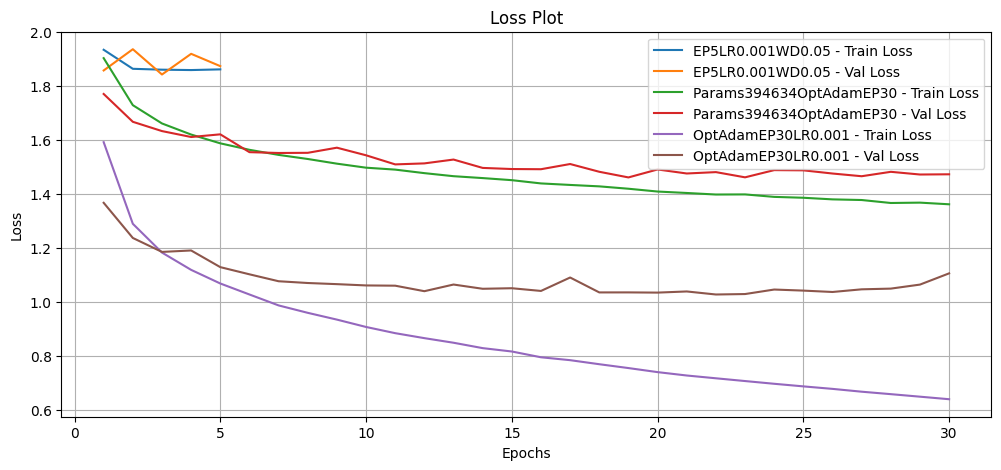

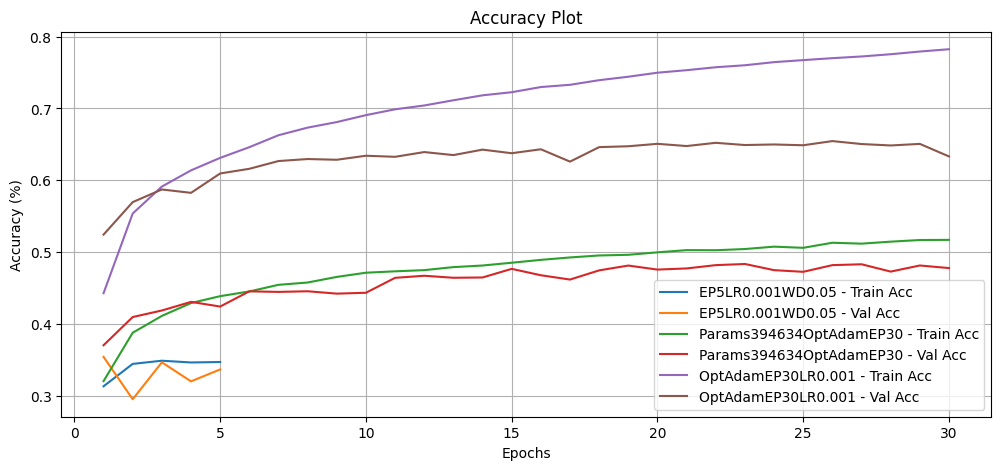

In [186]:
plot_training_results()


### Comment
* Green and red graph lines are our first model
* purple and brown are our First CNN checks

Our First CNN shows significant improvement:
* Accuracy of test raises to .88
* Accuracy of Val raises to 0.65

Confrimation of expected gain:
* We confirm that compared to previous model we had aproximately 10% accuracy increase

Problem:
* We see an overfitting as the val and test accuracy are not raising to same levels
* The Validation Loss is climbing at 25-30 Epochs, we expect it to fall


## Deeper CNN
Next we start improving our CNN
To address the Overfitting we add Batch Normalidation and 2 Conv2d layers

### Building the Networks

#### Deeper CNN - 1

In [187]:
class CNNBatchNormModel(nn.Module):
    def __init__(self, num_classes=10):
        super(CNNBatchNormModel, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding="same")
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding="same")
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.fc1 = nn.Linear(64 * 8 * 8, num_classes)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        x = torch.flatten(x, start_dim=1)
        x = self.fc1(x)
        
        return x

In [190]:
hp = {
    "epochs":30,
    "batch_size":128,
    "lr": 0.001,
    "weight_decay":0.00,
    "optimizer":"Adam"
    }

train_loader = DataLoader(train_data, batch_size=hp["batch_size"], shuffle=True)
test_loader = DataLoader(test_data, batch_size=hp["batch_size"], shuffle=False)
model = CNNBatchNormModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=hp["lr"], weight_decay=hp["weight_decay"])
criterion = nn.CrossEntropyLoss()

In [191]:
train_losses, train_accuracies, val_losses, val_accuracies = train_validate(model, train_loader, test_loader, epochs=hp["epochs"])

Train Epoch: 1 [0/50000 (0%)]	Loss: 2.382439
Train Epoch: 1 [25600/50000 (51%)]	Loss: 1.288370

Validation set: Average loss: 1.3325, Accuracy: 5416/10000 (54.16%)

Train Epoch: 2 [0/50000 (0%)]	Loss: 0.896908
Train Epoch: 2 [25600/50000 (51%)]	Loss: 0.976353

Validation set: Average loss: 1.1200, Accuracy: 6129/10000 (61.29%)

Train Epoch: 3 [0/50000 (0%)]	Loss: 0.904193
Train Epoch: 3 [25600/50000 (51%)]	Loss: 0.824467

Validation set: Average loss: 0.9504, Accuracy: 6719/10000 (67.19%)

Train Epoch: 4 [0/50000 (0%)]	Loss: 0.710432
Train Epoch: 4 [25600/50000 (51%)]	Loss: 0.777253

Validation set: Average loss: 0.9318, Accuracy: 6784/10000 (67.84%)

Train Epoch: 5 [0/50000 (0%)]	Loss: 0.607980
Train Epoch: 5 [25600/50000 (51%)]	Loss: 0.724230

Validation set: Average loss: 0.8683, Accuracy: 7075/10000 (70.75%)

Train Epoch: 6 [0/50000 (0%)]	Loss: 0.589968
Train Epoch: 6 [25600/50000 (51%)]	Loss: 0.821115

Validation set: Average loss: 0.9268, Accuracy: 6903/10000 (69.03%)

Train Epoc

In [192]:
model_name = create_model_name(model, hp)
df = store_results(model_name, train_losses, train_accuracies, val_losses, val_accuracies, hp["epochs"])
df.head()

,Epoch,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy,Model Name
0,1,1.934157,0.31294,1.857626,0.3539,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
1,2,1.863742,0.34412,1.936205,0.2949,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
2,3,1.860499,0.34854,1.842625,0.3463,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
3,4,1.859108,0.34610,1.919166,0.3198,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
4,5,1.861645,0.34672,1.873598,0.3364,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05


In [194]:
create_model_name(model, hp)

'CNN_Conv2_Params60554_OptAdam_EP30_LR0.001_WD0.0'

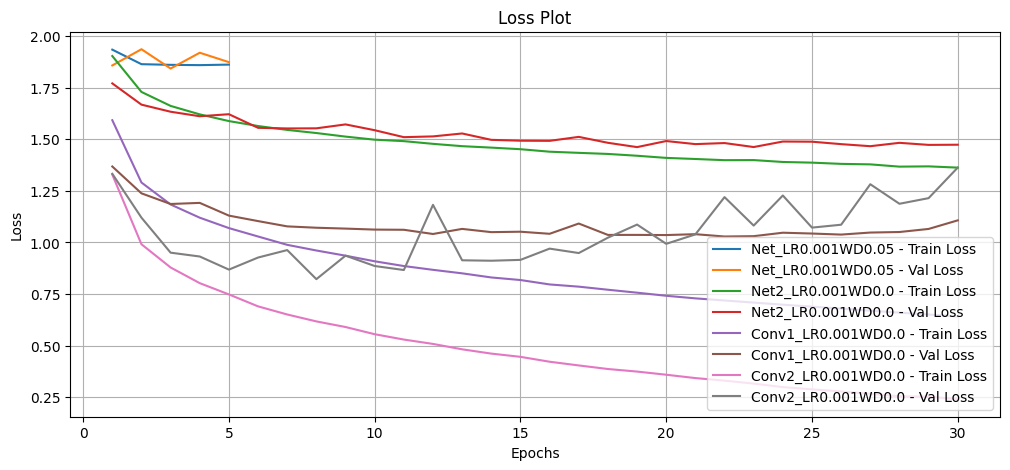

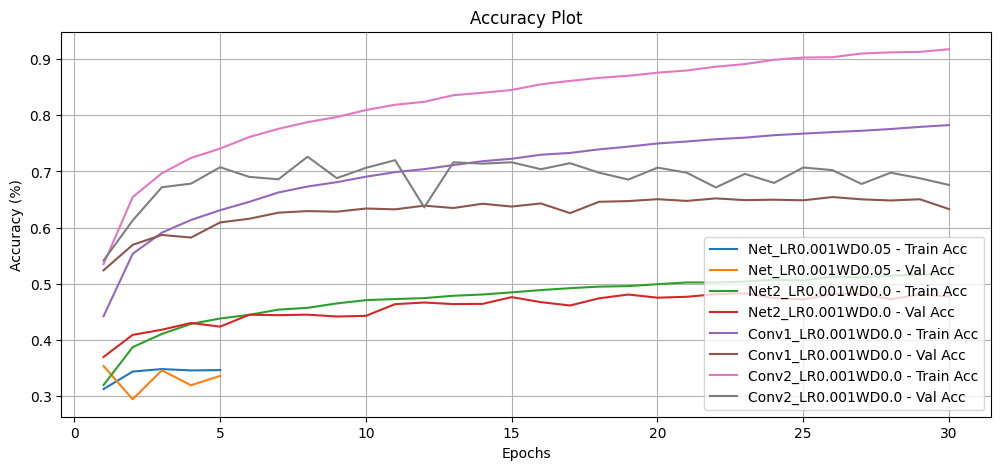

In [215]:
plot_training_results()

### Comment
The changes to model 2 resulted in the following:
* The train loss rapidly went down
* The Validation loss however shows a raising tendency after 15 Epochs

Accuracy:
* The accuracy of train is significantly better
* The accuracy of validation is only slightly better than the previous model
* Significant overfitting can be observed as the train and validation error are showing a big difference betwee each other.
* After 30 Epochs Train accuracy is aproximately 0.92 while validation accuracy is at 0.68

#### Deeper CNN - 2

To mitigate the overfitting, we incorporated Dropout in the second model. This should reduce the overfitting and help the model generalize better.


In [ ]:
class CNNBatchNormDropoutModel(nn.Module):
    def __init__(self, num_classes=10, dropout_prob=0.5):
        super(CNNBatchNormDropoutModel, self).__init__()

        # First Conv Block
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding="same")
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout(p=dropout_prob)  # Dropout

        # Second Conv Block
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding="same")
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout2 = nn.Dropout(p=dropout_prob)  # Dropout

        # Fully Connected Layer
        self.fc1 = nn.Linear(64 * 8 * 8, num_classes)
        self.dropout_fc = nn.Dropout(p=dropout_prob)  # Dropout

    def forward(self, x):
        # --- First Conv Block ---
        x = self.conv1(x)  # (N, 32, 32, 32)
        x = self.bn1(x)  # (N, 32, 32, 32)
        x = self.relu1(x)  # (N, 32, 32, 32)
        x = self.pool1(x)  # (N, 32, 16, 16)
        x = self.dropout1(x)  # Dropout applied

        # --- Second Conv Block ---
        x = self.conv2(x)  # (N, 64, 16, 16)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)  # (N, 64, 8, 8)
        x = self.dropout2(x)  # Dropout applied

        # --- Fully Connected Layer ---
        x = torch.flatten(x, start_dim=1)  # (N, 64, 8, 8)
        x = self.dropout_fc(x)  # Dropout applied
        x = self.fc1(x)  # (N, num_classes)

        return x

In [217]:
hp = {
    "epochs":30,
    "batch_size":128,
    "lr": 0.001,
    "weight_decay":0.00,
    "optimizer":"Adam"
    }

train_loader = DataLoader(train_data, batch_size=hp["batch_size"], shuffle=True)
test_loader = DataLoader(test_data, batch_size=hp["batch_size"], shuffle=False)
model = CNNBatchNormDropoutModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=hp["lr"], weight_decay=hp["weight_decay"])
criterion = nn.CrossEntropyLoss()

In [218]:
train_losses, train_accuracies, val_losses, val_accuracies = train_validate(model, train_loader, test_loader, epochs=hp["epochs"])

Train Epoch: 1 [0/50000 (0%)]	Loss: 3.057982
Train Epoch: 1 [25600/50000 (51%)]	Loss: 1.764087

Validation set: Average loss: 1.3708, Accuracy: 5097/10000 (50.97%)

Train Epoch: 2 [0/50000 (0%)]	Loss: 1.447899
Train Epoch: 2 [25600/50000 (51%)]	Loss: 1.380726

Validation set: Average loss: 1.2419, Accuracy: 5765/10000 (57.65%)

Train Epoch: 3 [0/50000 (0%)]	Loss: 1.319160
Train Epoch: 3 [25600/50000 (51%)]	Loss: 1.288619

Validation set: Average loss: 1.2165, Accuracy: 5829/10000 (58.29%)

Train Epoch: 4 [0/50000 (0%)]	Loss: 1.319494
Train Epoch: 4 [25600/50000 (51%)]	Loss: 1.256016

Validation set: Average loss: 1.1394, Accuracy: 6196/10000 (61.96%)

Train Epoch: 5 [0/50000 (0%)]	Loss: 1.182747
Train Epoch: 5 [25600/50000 (51%)]	Loss: 1.155719

Validation set: Average loss: 1.0825, Accuracy: 6359/10000 (63.59%)

Train Epoch: 6 [0/50000 (0%)]	Loss: 1.063381
Train Epoch: 6 [25600/50000 (51%)]	Loss: 1.059756

Validation set: Average loss: 1.0870, Accuracy: 6351/10000 (63.51%)

Train Epoc

In [221]:
create_model_name(model, hp)

'CNNBatchNormDropoutModel_Conv2_Params60554_OptAdam_EP30_LR0.001_WD0.0'

In [222]:
model_name = create_model_name(model, hp)
df = store_results(model_name, train_losses, train_accuracies, val_losses, val_accuracies, hp["epochs"])
df.head()

,Epoch,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy,Model Name
0,1,1.934157,0.31294,1.857626,0.3539,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
1,2,1.863742,0.34412,1.936205,0.2949,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
2,3,1.860499,0.34854,1.842625,0.3463,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
3,4,1.859108,0.34610,1.919166,0.3198,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
4,5,1.861645,0.34672,1.873598,0.3364,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05


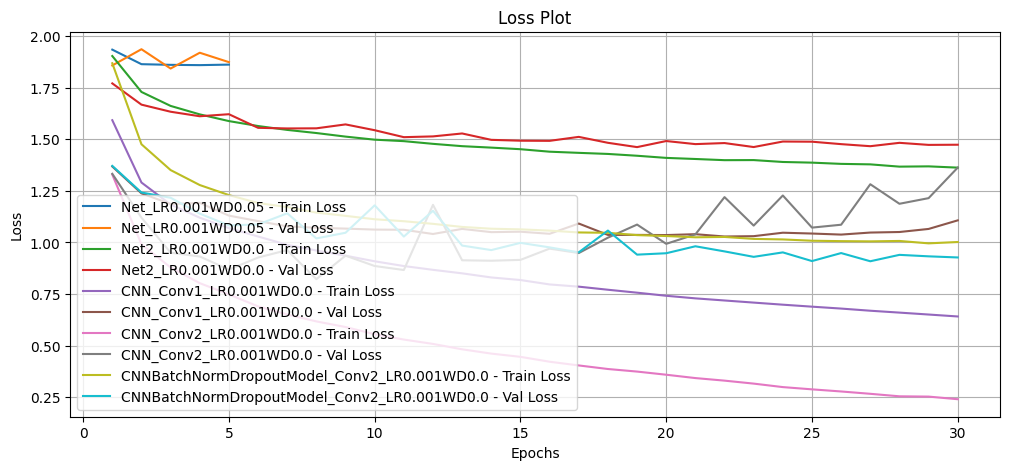

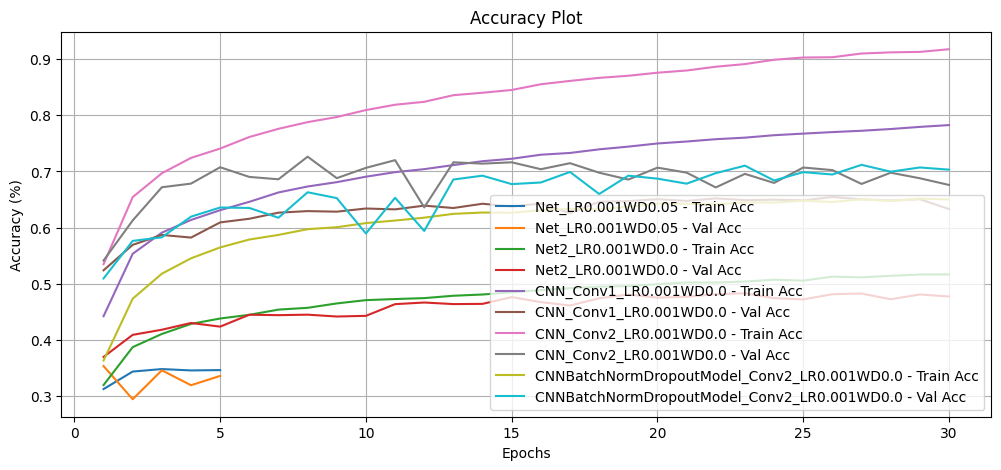

In [225]:
plot_training_results()

### Comment
Our Model 3 shows the following traits:
* Accuracy of Train and validation are now very close to each other
* The accuracy of aproximately .68-0.7 is so far the highest

Loss:
* Train and Validation loss remain significant but in same range as previous models

#### Deeper CNN - 3
To address underfitting the next model should have a higher complexity.
We expanded the number of output channels of the convolutional layers.
It now has 64 channels in the first layer
128 channels in the second layer

We expect this to be performing better than CNN-2

In [ ]:
import torch
import torch.nn as nn

class CNNLarge(nn.Module):
    def __init__(self, num_classes=10, dropout_prob=0.5):
        super(CNNLarge, self).__init__()

        # First Conv Block (More Filters)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding="same")
        self.bn1 = nn.BatchNorm2d(64)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout(p=dropout_prob)  # Dropout after first block

        # Second Conv Block (More Filters)
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding="same")
        self.bn2 = nn.BatchNorm2d(128)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout2 = nn.Dropout(p=dropout_prob)  # Dropout after second block

        # Fully Connected Layer 
        self.fc1 = nn.Linear(128 * 8 * 8, num_classes) 

    def forward(self, x):
        # --- First Conv Block ---
        x = self.conv1(x)  # (N, 64, 32, 32)
        x = self.bn1(x) 
        x = self.relu1(x)
        x = self.pool1(x)  # (N, 64, 16, 16)
        x = self.dropout1(x)  # Dropout applied

        # --- Second Conv Block ---
        x = self.conv2(x)  #  (N, 128, 16, 16)
        x = self.bn2(x)  # (N, 128, 16, 16)
        x = self.relu2(x)  # (N, 128, 16, 16)
        x = self.pool2(x)  # (N, 128, 8, 8)
        x = self.dropout2(x)  # Dropout applied

        # --- Fully Connected Layer ---
        x = torch.flatten(x, start_dim=1)  # (N, 8192)
        x = self.fc1(x)  # (N, num_classes)

        return x


In [231]:
hp = {
    "epochs":30,
    "batch_size":128,
    "lr": 0.001,
    "weight_decay":0.00,
    "optimizer":"Adam"
    }

train_loader = DataLoader(train_data, batch_size=hp["batch_size"], shuffle=True)
test_loader = DataLoader(test_data, batch_size=hp["batch_size"], shuffle=False)
model = CNNLarge().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=hp["lr"], weight_decay=hp["weight_decay"])
criterion = nn.CrossEntropyLoss()

In [232]:
train_losses, train_accuracies, val_losses, val_accuracies = train_validate(model, train_loader, test_loader, epochs=hp["epochs"])

Train Epoch: 1 [0/50000 (0%)]	Loss: 2.646634
Train Epoch: 1 [25600/50000 (51%)]	Loss: 1.612006

Validation set: Average loss: 1.1906, Accuracy: 5783/10000 (57.83%)

Train Epoch: 2 [0/50000 (0%)]	Loss: 1.378082
Train Epoch: 2 [25600/50000 (51%)]	Loss: 1.385883

Validation set: Average loss: 1.0644, Accuracy: 6257/10000 (62.57%)

Train Epoch: 3 [0/50000 (0%)]	Loss: 1.023694
Train Epoch: 3 [25600/50000 (51%)]	Loss: 0.931956

Validation set: Average loss: 1.0735, Accuracy: 6315/10000 (63.15%)

Train Epoch: 4 [0/50000 (0%)]	Loss: 1.098316
Train Epoch: 4 [25600/50000 (51%)]	Loss: 0.961378

Validation set: Average loss: 0.9899, Accuracy: 6637/10000 (66.37%)

Train Epoch: 5 [0/50000 (0%)]	Loss: 0.905967
Train Epoch: 5 [25600/50000 (51%)]	Loss: 0.972363

Validation set: Average loss: 0.9846, Accuracy: 6538/10000 (65.38%)

Train Epoch: 6 [0/50000 (0%)]	Loss: 0.804441
Train Epoch: 6 [25600/50000 (51%)]	Loss: 0.833387

Validation set: Average loss: 0.8831, Accuracy: 6986/10000 (69.86%)

Train Epoc

In [233]:
model_name = create_model_name(model, hp)
df = store_results(model_name, train_losses, train_accuracies, val_losses, val_accuracies, hp["epochs"])
df.head()

,Epoch,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy,Model Name
0,1,1.934157,0.31294,1.857626,0.3539,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
1,2,1.863742,0.34412,1.936205,0.2949,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
2,3,1.860499,0.34854,1.842625,0.3463,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
3,4,1.859108,0.34610,1.919166,0.3198,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
4,5,1.861645,0.34672,1.873598,0.3364,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05


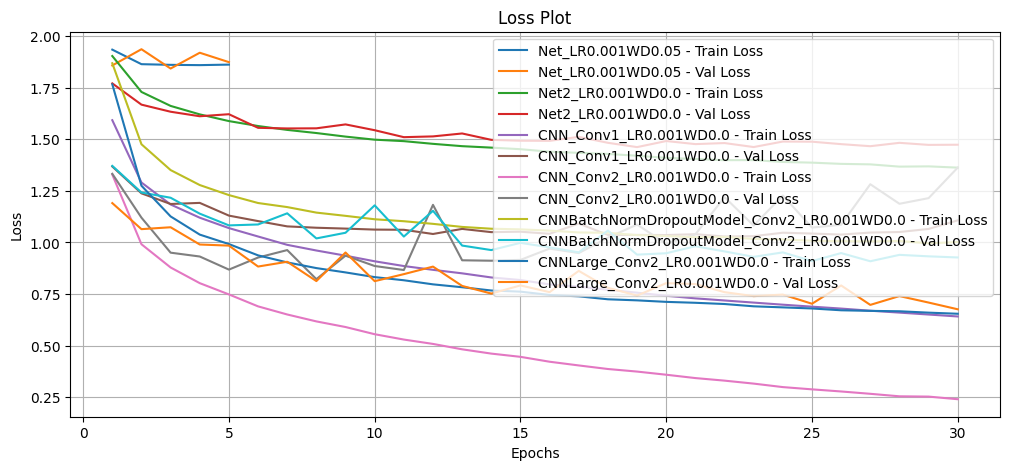

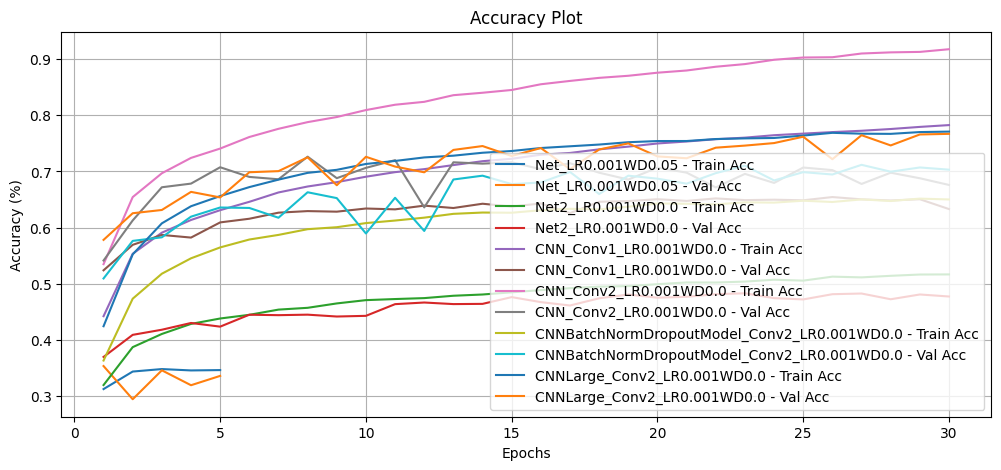

In [234]:
plot_training_results()

### Comment
Performance of last model, loss
* Loss is still decreasing after 30 epochs
* We are slowly getting down

Accuracy:
* Highest accuracy shown in validation
* train accuracy not very high
* No sign of majoir overfitting

#### Deeper CNN - 4

Next trial is to change the kernel size to 5x5.
To test this effect we use a single layer model

In [242]:
class CNN5x5(nn.Module):
    def __init__(self, num_classes=10, dropout_prob=0.5):
        super(CNN5x5, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=5, stride=1, padding="same")
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout(p=dropout_prob)
        
        self.fc1 = nn.Linear(32 * 16 * 16, num_classes)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.dropout1(x)
        
        x = torch.flatten(x, start_dim=1)
        x = self.fc1(x)
        
        return x

In [243]:
hp = {
    "epochs":30,
    "batch_size":128,
    "lr": 0.001,
    "weight_decay":0.00,
    "optimizer":"Adam"
    }

train_loader = DataLoader(train_data, batch_size=hp["batch_size"], shuffle=True)
test_loader = DataLoader(test_data, batch_size=hp["batch_size"], shuffle=False)
model = CNN5x5().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=hp["lr"], weight_decay=hp["weight_decay"])
criterion = nn.CrossEntropyLoss()

In [244]:
train_losses, train_accuracies, val_losses, val_accuracies = train_validate(model, train_loader, test_loader, epochs=hp["epochs"])

Train Epoch: 1 [0/50000 (0%)]	Loss: 2.559985
Train Epoch: 1 [25600/50000 (51%)]	Loss: 1.378029

Validation set: Average loss: 1.4824, Accuracy: 4978/10000 (49.78%)

Train Epoch: 2 [0/50000 (0%)]	Loss: 1.565048
Train Epoch: 2 [25600/50000 (51%)]	Loss: 1.410410

Validation set: Average loss: 1.2569, Accuracy: 5694/10000 (56.94%)

Train Epoch: 3 [0/50000 (0%)]	Loss: 1.241990
Train Epoch: 3 [25600/50000 (51%)]	Loss: 1.251298

Validation set: Average loss: 1.2513, Accuracy: 5871/10000 (58.71%)

Train Epoch: 4 [0/50000 (0%)]	Loss: 1.241791
Train Epoch: 4 [25600/50000 (51%)]	Loss: 1.265970

Validation set: Average loss: 1.1310, Accuracy: 6074/10000 (60.74%)

Train Epoch: 5 [0/50000 (0%)]	Loss: 1.205197
Train Epoch: 5 [25600/50000 (51%)]	Loss: 1.042195

Validation set: Average loss: 1.0934, Accuracy: 6266/10000 (62.66%)

Train Epoch: 6 [0/50000 (0%)]	Loss: 1.051508
Train Epoch: 6 [25600/50000 (51%)]	Loss: 1.028830

Validation set: Average loss: 1.0786, Accuracy: 6227/10000 (62.27%)

Train Epoc

In [245]:
model_name = create_model_name(model, hp)
df = store_results(model_name, train_losses, train_accuracies, val_losses, val_accuracies, hp["epochs"])
df.head()

,Epoch,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy,Model Name
0,1,1.934157,0.31294,1.857626,0.3539,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
1,2,1.863742,0.34412,1.936205,0.2949,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
2,3,1.860499,0.34854,1.842625,0.3463,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
3,4,1.859108,0.34610,1.919166,0.3198,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
4,5,1.861645,0.34672,1.873598,0.3364,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05


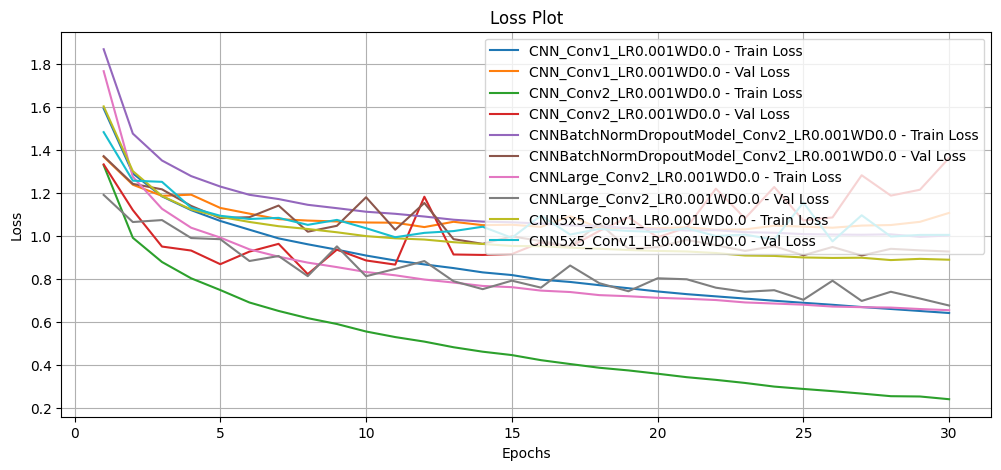

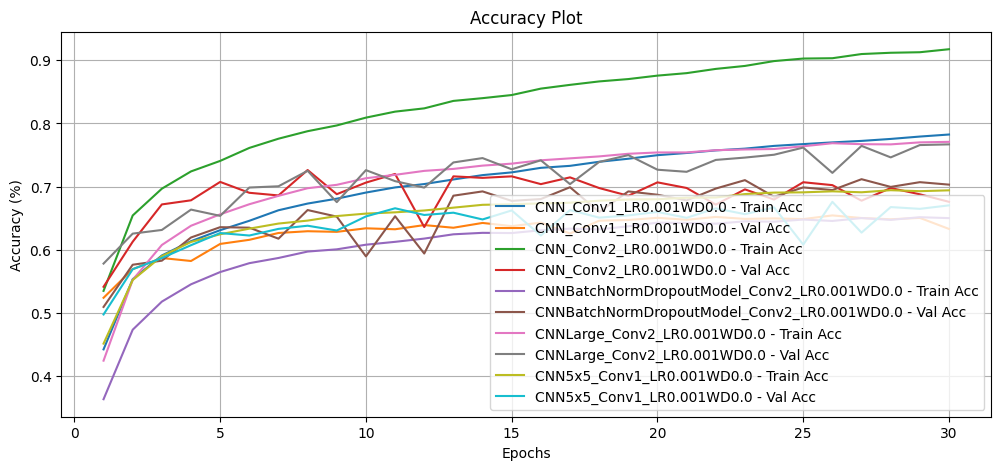

In [4]:
plot_training_results(only_cnn=True)

## Comment
Summary of the 4 CNN Models
__Remarks:__

### CNN1
Name in Dataframe: (CNN_Conv2_Params60554_OptAdam_EP30_LR0.001_WD0.0)
Graph named: "CNN_Conv2*"

In the first model, we added Batch Normalization and introduced an additional convolutional layer with 64 output channels. While this significantly improved training accuracy, the validation accuracy declined, indicating overfitting.

### CNN2
Name in Dataframe: (CNNBatchNormDropoutModel_Conv2_Params60554_OptAdam_EP30_LR0.001_WD0.0)
Graph named: "CNNBatchNormDropoutModel*"

To mitigate this, we incorporated Dropout in the second model. Interestingly, this led to better validation performance than training performance, suggesting that the model benefited from regularization. However, the overall performance did not improve significantly.

### CNN3
Name in Dataframe: (CNNLarge_Conv2_Params157962_OptAdam_EP30_LR0.001_WD0.0)
Graph named: "CNNLarge_Conv2*"

To further address underfitting, we increased the model’s complexity by expanding the number of output channels in the convolutional layers. The third model, featuring 64 channels in the first convolutional layer and 128 in the second, is the most complex architecture so far. However, it still failed to provide a noticeable improvement in overall performance.

### CNN4
Name in Dataframe: (CNN5x5_Conv1_Params84426_OptAdam_EP30_LR0.001_WD0.0) Again only one convolutional
Graph named: "CNN5x5*"

Additionally, we tested a simpler model with a single convolutional layer using a 5×5 kernel. However, this model failed to achieve competitive results throughout all 30 epochs of training, further reinforcing the importance of deeper architectures in achieving better generalization.

Next code to get the table showing final results of our 4 CNN's

In [4]:
import pandas as pd
df = pd.read_csv("model_training_results.csv")
df.head()

,Epoch,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy,Model Name
0,1,1.934157,0.31294,1.857626,0.3539,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
1,2,1.863742,0.34412,1.936205,0.2949,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
2,3,1.860499,0.34854,1.842625,0.3463,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
3,4,1.859108,0.34610,1.919166,0.3198,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05
4,5,1.861645,0.34672,1.873598,0.3364,Net_Params30730_OptAdam_EP5_LR0.001_WD0.05


In [10]:
set(df["Model Name"])

{'CNN5x5_Conv1_Params84426_OptAdam_EP30_LR0.001_WD0.0',
 'CNNBatchNormDropoutModel_Conv2_Params60554_OptAdam_EP30_LR0.001_WD0.0',
 'CNNLarge_Conv2_Params157962_OptAdam_EP30_LR0.001_WD0.0',
 'CNN_Conv1_Params82826_OptAdam_EP30_LR0.001_WD0.0',
 'CNN_Conv2_Params60554_OptAdam_EP30_LR0.001_WD0.0',
 'Net_Params30730_OptAdam_EP5_LR0.001_WD0.05',
 'Net_two_layers_Params394634_OptAdam_EP30_LR0.001_WD0.0'}

In [5]:
copy_df = df[(df["Epoch"] == 30) & (df["Model Name"].str.contains("CNN"))]
test = copy_df.reset_index()
df_new = test.drop("index", axis=1)
df_new.drop(0, inplace=True)

test = df_new.reset_index()
df_new = test.drop("index", axis=1)
df_new

,Epoch,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy,Model Name
0,30,0.240232,0.91742,1.362684,0.6760,CNN_Conv2_Params60554_OptAdam_EP30_LR0.001_WD0.0
1,30,1.002039,0.65022,0.927153,0.7032,CNNBatchNormDropoutModel_Conv2_Params60554_OptAdam_EP30_LR0.001_WD0.0
2,30,0.654349,0.77088,0.676003,0.7669,CNNLarge_Conv2_Params157962_OptAdam_EP30_LR0.001_WD0.0
3,30,0.889049,0.69420,1.004644,0.6704,CNN5x5_Conv1_Params84426_OptAdam_EP30_LR0.001_WD0.0


In [6]:
df_new = (
    df[(df["Epoch"] == 30) & (df["Model Name"].str.contains("CNN"))]
    .reset_index(drop=True)
    .iloc[1:]
)

df_new = df_new.reset_index()
df_new = df_new.drop("index", axis=1)
df_new

,Epoch,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy,Model Name
0,30,0.240232,0.91742,1.362684,0.6760,CNN_Conv2_Params60554_OptAdam_EP30_LR0.001_WD0.0
1,30,1.002039,0.65022,0.927153,0.7032,CNNBatchNormDropoutModel_Conv2_Params60554_OptAdam_EP30_LR0.001_WD0.0
2,30,0.654349,0.77088,0.676003,0.7669,CNNLarge_Conv2_Params157962_OptAdam_EP30_LR0.001_WD0.0
3,30,0.889049,0.69420,1.004644,0.6704,CNN5x5_Conv1_Params84426_OptAdam_EP30_LR0.001_WD0.0


In [7]:
import pandas as pd

# Define model summary strings
summary_str_1 = "Layer 1: Conv D=32, w=h=3, S=1, P='same' | Layer 2: MAXPOOL w=h=2, S=2 | Layer 3: Conv D=64, w=h=3, S=1, P='same' | Layer 4: MAXPOOL w=h=2, S=2 | Layer 5: FLATTEN | Layer 6: FC out=10"
summary_str_2 = "Layer 1: Conv D=32, w=h=3, S=1, P='same' | Layer 2: MAXPOOL w=h=2, S=2 | Layer 3: DROPOUT p=0.5 | Layer 4: Conv D=64, w=h=3, S=1, P='same' | Layer 5: MAXPOOL w=h=2, S=2 | Layer 6: DROPOUT p=0.5 | Layer 7: FLATTEN | Layer 8: DROPOUT p=0.5 | Layer 9: FC out=10"
summary_str_3 = "Layer 1: Conv D=64, w=h=3, S=1, P='same' | Layer 2: MAXPOOL w=h=2, S=2 | Layer 3: DROPOUT p=0.5 | Layer 4: Conv D=128, w=h=3, S=1, P='same' | Layer 5: MAXPOOL w=h=2, S=2 | Layer 6: DROPOUT p=0.5 | Layer 7: FLATTEN | Layer 8: FC out=10"
summary_str_4 = "Layer 1: Conv D=32, w=h=5, S=1, P='same' | Layer 2: BatchNorm | Layer 3: ReLU | Layer 4: MAXPOOL w=h=2, S=2 | Layer 5: DROPOUT p=0.5 | Layer 6: FLATTEN | Layer 7: FC out=10"

# Create a DataFrame with a single column "model"
df_models = pd.DataFrame({"model": [summary_str_1, summary_str_2, summary_str_3, summary_str_4]})
pd.set_option('display.max_colwidth', None)
# Display the DataFrame
print(df_models)


                                                                                                                                                                                                                                                                model
0                                                                             Layer 1: Conv D=32, w=h=3, S=1, P='same' | Layer 2: MAXPOOL w=h=2, S=2 | Layer 3: Conv D=64, w=h=3, S=1, P='same' | Layer 4: MAXPOOL w=h=2, S=2 | Layer 5: FLATTEN | Layer 6: FC out=10
1  Layer 1: Conv D=32, w=h=3, S=1, P='same' | Layer 2: MAXPOOL w=h=2, S=2 | Layer 3: DROPOUT p=0.5 | Layer 4: Conv D=64, w=h=3, S=1, P='same' | Layer 5: MAXPOOL w=h=2, S=2 | Layer 6: DROPOUT p=0.5 | Layer 7: FLATTEN | Layer 8: DROPOUT p=0.5 | Layer 9: FC out=10
2                          Layer 1: Conv D=64, w=h=3, S=1, P='same' | Layer 2: MAXPOOL w=h=2, S=2 | Layer 3: DROPOUT p=0.5 | Layer 4: Conv D=128, w=h=3, S=1, P='same' | Layer 5: MAXPOOL w=h=2, S=2 | Layer 6: DROPOU

### Comment
The table showing the final train and validation accuracies of our CNN's
Also showing the configuration of each

#### Next
* Next step would be changes to the kernel size while keeping the multi layer architecture
* try more layers
* Try effect of e.g. training additional 30 epochs to 60 epochs

In [9]:
df_combined = pd.concat([df_models, df_new], axis=1).drop(["Model Name", "Epoch"], axis=1)
df_combined

,model,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy
0,"Layer 1: Conv D=32, w=h=3, S=1, P='same' | Layer 2: MAXPOOL w=h=2, S=2 | Layer 3: Conv D=64, w=h=3, S=1, P='same' | Layer 4: MAXPOOL w=h=2, S=2 | Layer 5: FLATTEN | Layer 6: FC out=10",0.240232,0.91742,1.362684,0.6760
1,"Layer 1: Conv D=32, w=h=3, S=1, P='same' | Layer 2: MAXPOOL w=h=2, S=2 | Layer 3: DROPOUT p=0.5 | Layer 4: Conv D=64, w=h=3, S=1, P='same' | Layer 5: MAXPOOL w=h=2, S=2 | Layer 6: DROPOUT p=0.5 | Layer 7: FLATTEN | Layer 8: DROPOUT p=0.5 | Layer 9: FC out=10",1.002039,0.65022,0.927153,0.7032
2,"Layer 1: Conv D=64, w=h=3, S=1, P='same' | Layer 2: MAXPOOL w=h=2, S=2 | Layer 3: DROPOUT p=0.5 | Layer 4: Conv D=128, w=h=3, S=1, P='same' | Layer 5: MAXPOOL w=h=2, S=2 | Layer 6: DROPOUT p=0.5 | Layer 7: FLATTEN | Layer 8: FC out=10",0.654349,0.77088,0.676003,0.7669
3,"Layer 1: Conv D=32, w=h=5, S=1, P='same' | Layer 2: BatchNorm | Layer 3: ReLU | Layer 4: MAXPOOL w=h=2, S=2 | Layer 5: DROPOUT p=0.5 | Layer 6: FLATTEN | Layer 7: FC out=10",0.889049,0.69420,1.004644,0.6704
